<a href="https://colab.research.google.com/github/FurqanAhmad019/24i-2534/blob/main/Lab04/24i2534_DS_5A_Lab04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [22]:
df = pd.read_csv("Sample - Superstore.csv", encoding = "latin1")
df.head()
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

# Task 1

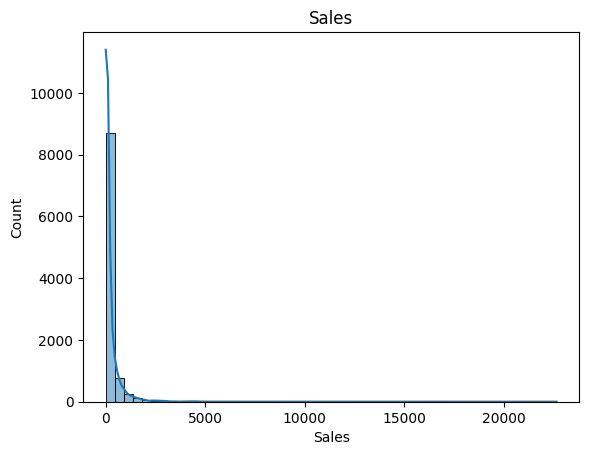

Skewness:  12.97275234181623
Mean:  229.85800083049833
Median:  54.489999999999995
Data is highly right skewed because almost all of the sales are at the left side of graph. Mean of the data is also highly greater than its median, showing high skewness.


In [18]:
sns.histplot(df["Sales"], kde = True, bins = 50)
plt.title("Sales")
plt.show()

print("Skewness: ", df['Sales'].skew())
print("Mean: ", df['Sales'].mean())
print("Median: ", df['Sales'].median())

print("Data is highly right skewed because almost all of the sales are at the left side of graph. Mean of the data is also highly greater than its median, showing high skewness.")

# Task 2

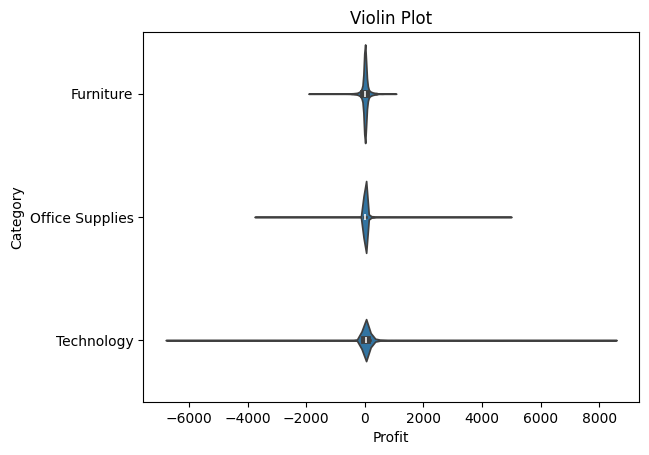

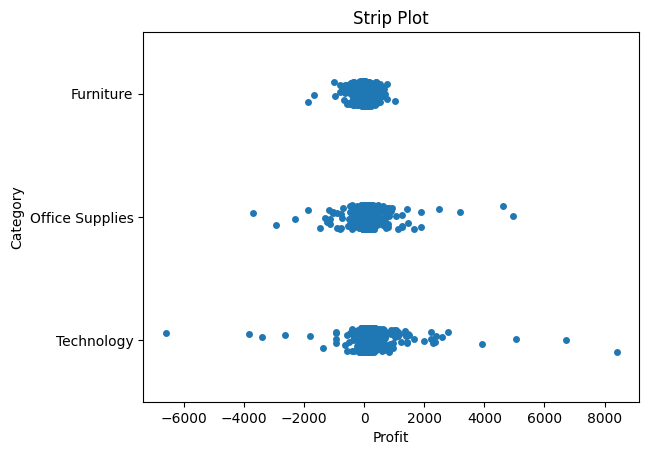

Violin plot is better for understanding because it shows better than strip plot


In [33]:
sns.violinplot(data=df, x='Profit', y='Category')
plt.title("Violin Plot")
plt.show()

sns.stripplot(data=df, x='Profit', y='Category', jitter=True)
plt.title("Strip Plot")
plt.show()

print("Violin plot is better for understanding because it shows better than strip plot")

# Task 3

Text(0.5, 1.0, 'Scatter Plot')

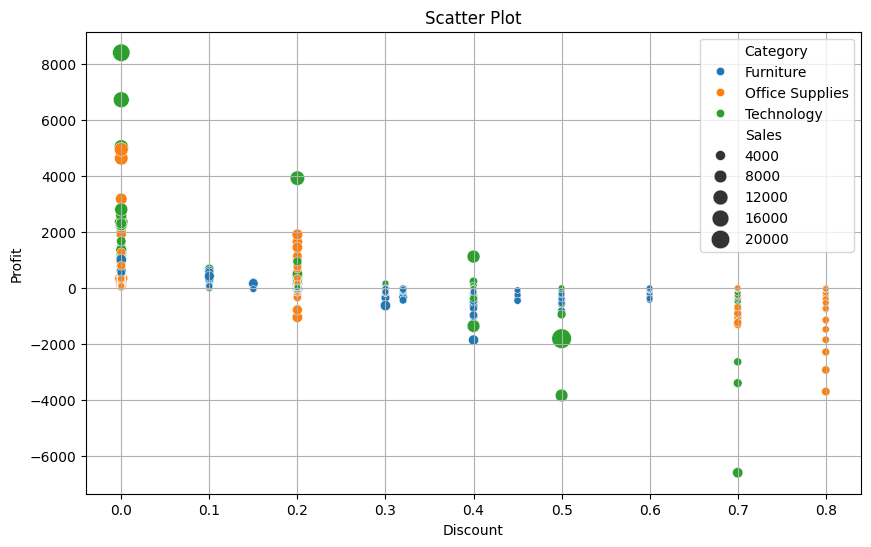

In [47]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data = df, x = 'Discount', y = 'Profit', hue = 'Category', size = "Sales", sizes = (20, 200))
plt.grid()
plt.title("Scatter Plot")

# Task 4

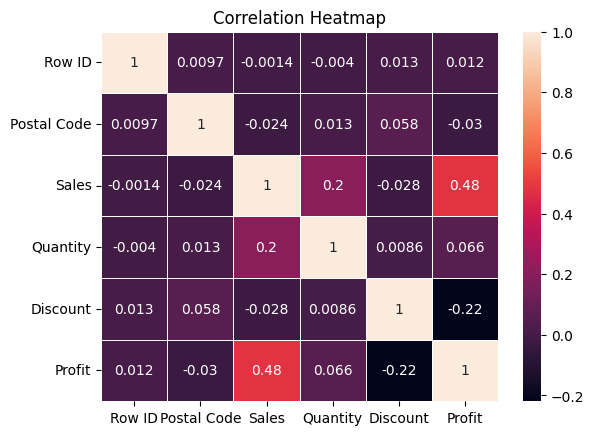

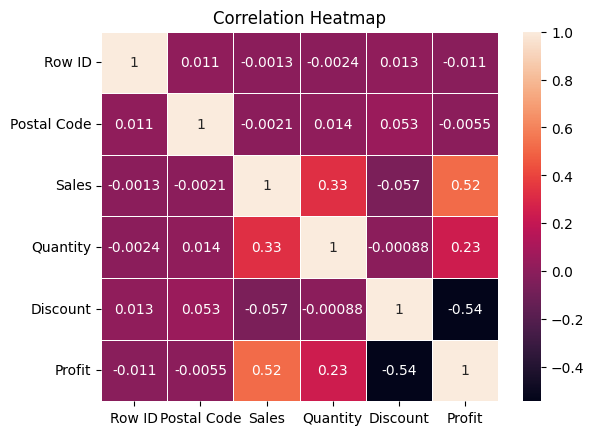

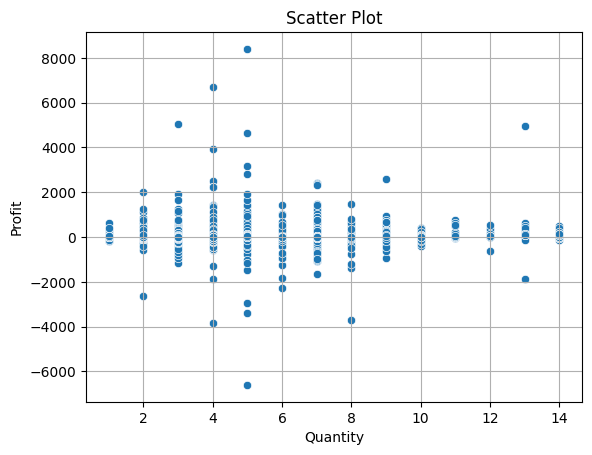

In [67]:
numerical_df = df.select_dtypes(include=['number'])

corr_matrix_pearson = numerical_df.corr(method = 'pearson')
corr_matrix_spearman = numerical_df.corr(method = 'spearman')

sns.heatmap(corr_matrix_pearson, annot=True, linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

sns.heatmap(corr_matrix_spearman, annot=True, linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

sns.scatterplot(data = df, x = 'Quantity', y = 'Profit')
plt.title("Scatter Plot")
plt.grid()
plt.show()

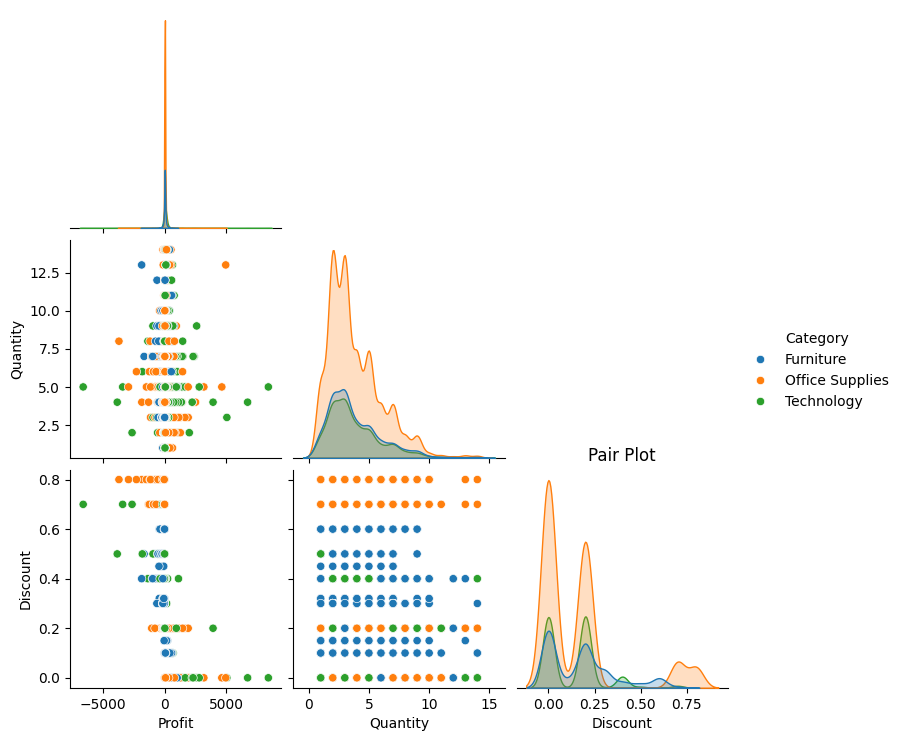

In [72]:
sns.pairplot(df, vars=['Profit', 'Quantity', 'Discount'], hue='Category', corner=True)
plt.title("Pair Plot")
plt.show()

# Task 5

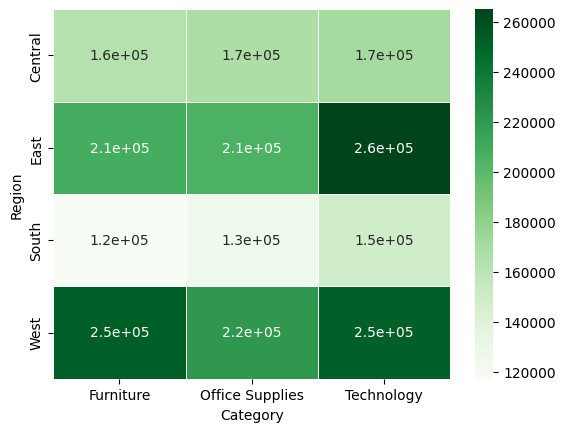

In [88]:
df.groupby('Category')['Sales'].agg(['mean', 'median', 'std', 'count'])
df.groupby(['Region', 'Category'])['Sales'].agg(['sum', 'mean'])
pd.pivot_table(df, index='Region', columns='Category', values='Sales', aggfunc='sum', margins=True)

sns.heatmap(df.pivot_table(index='Region', columns='Category', values='Sales', aggfunc='sum'), annot=True, linewidths=0.5, cmap='Greens')
plt.show()

# Task 6

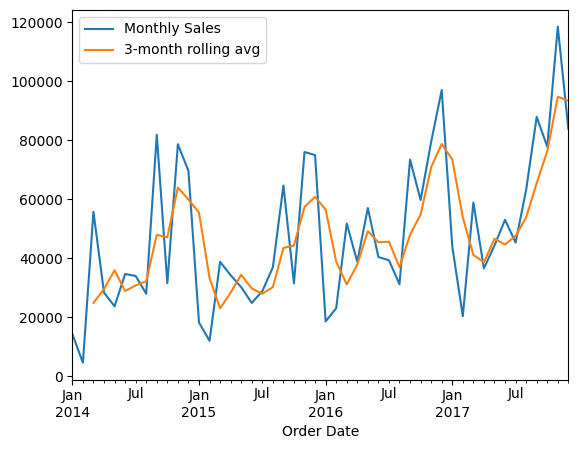

In [95]:
df_temp = pd.read_csv("Sample - Superstore.csv", encoding = "latin1")
df_temp['Order Date'] = pd.to_datetime(df_temp['Order Date'])
df_temp = df_temp.set_index('Order Date')
monthly = df_temp['Sales'].resample('ME').sum()
monthly_totals_rolling = monthly.rolling(window=3).mean()
monthly.plot(label='Monthly Sales')
monthly_totals_rolling.plot(label='3-month rolling avg')
plt.legend()
plt.show()

# Task 7

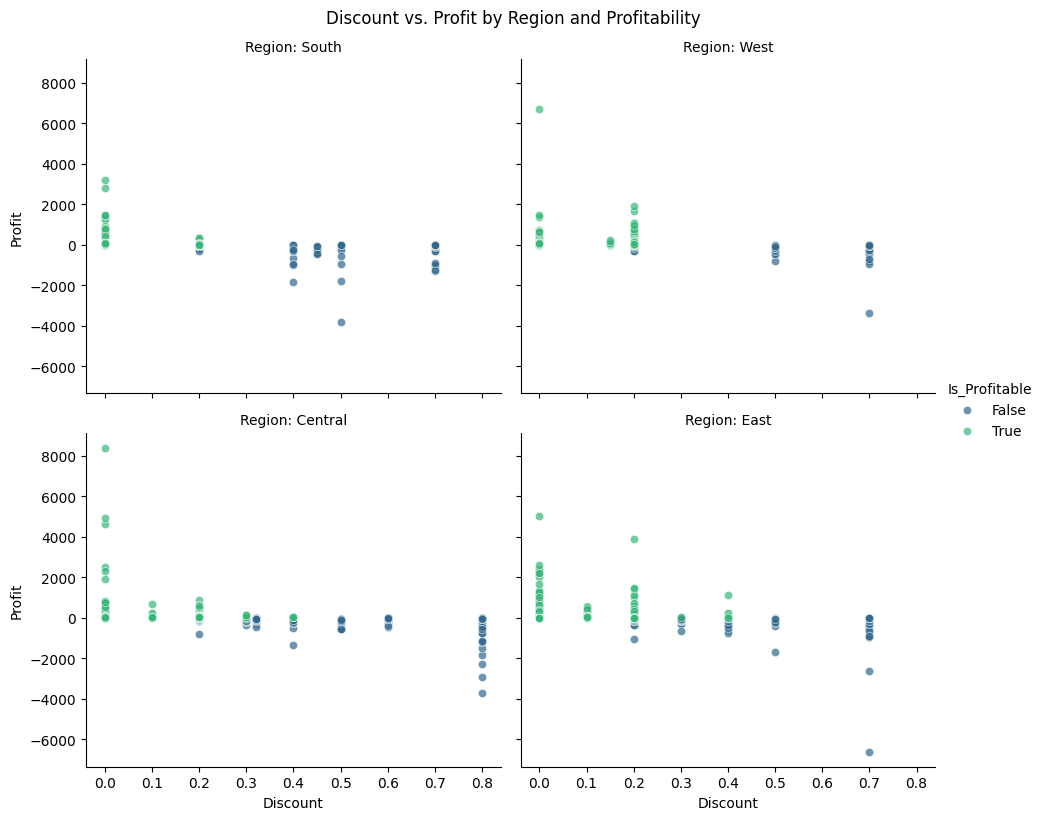

Central Region shows that higher discounts lead to negative profits more frequently than others


In [101]:
df['Is_Profitable'] = df['Profit'] > 0

g = sns.FacetGrid(df, col='Region', hue='Is_Profitable', col_wrap=2, height=4, aspect=1.2, palette='viridis')
g.map(sns.scatterplot, 'Discount', 'Profit', alpha=0.7)
g.add_legend()
g.set_axis_labels('Discount', 'Profit')
g.set_titles(col_template='Region: {col_name}')
plt.suptitle('Discount vs. Profit by Region and Profitability', y=1.02)
plt.show()

print("Central Region shows that higher discounts lead to negative profits more frequently than others")

# Task 8

### Overplotting + Annotation: Discount vs. Profit

First, let's look at a raw scatter plot of `Discount` vs `Profit`. You'll notice significant overplotting due to the large number of orders, making it hard to interpret the density of points.

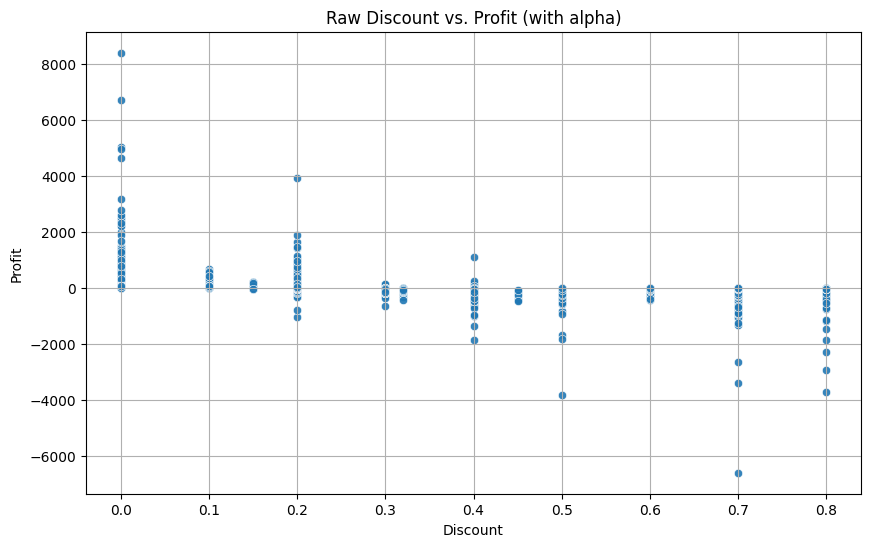

In [108]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.9)
plt.title('Raw Discount vs. Profit (with alpha)')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.grid(True)
plt.show()

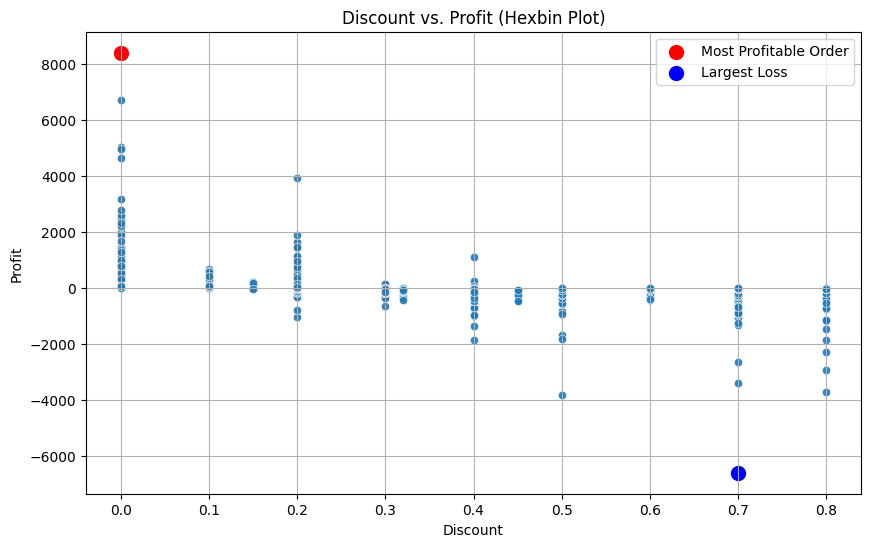

In [116]:

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.9)
plt.title('Discount vs. Profit (Hexbin Plot)')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.grid(True)

max_profit_value = df['Profit'].max()
min_profit_value = df['Profit'].min()

most_profitable_row = df[df['Profit'] == max_profit_value].iloc[0]
largest_loss_row = df[df['Profit'] == min_profit_value].iloc[0]

plt.scatter(most_profitable_row['Discount'], most_profitable_row['Profit'], color='red', s=100, label='Most Profitable Order')

plt.scatter(largest_loss_row['Discount'], largest_loss_row['Profit'], color='blue', s=100, label='Largest Loss')

plt.legend()
plt.show()